# Forbidden Attack on GCM with Repeated Nonces

---

# 1. AES-GCM Fundamentals
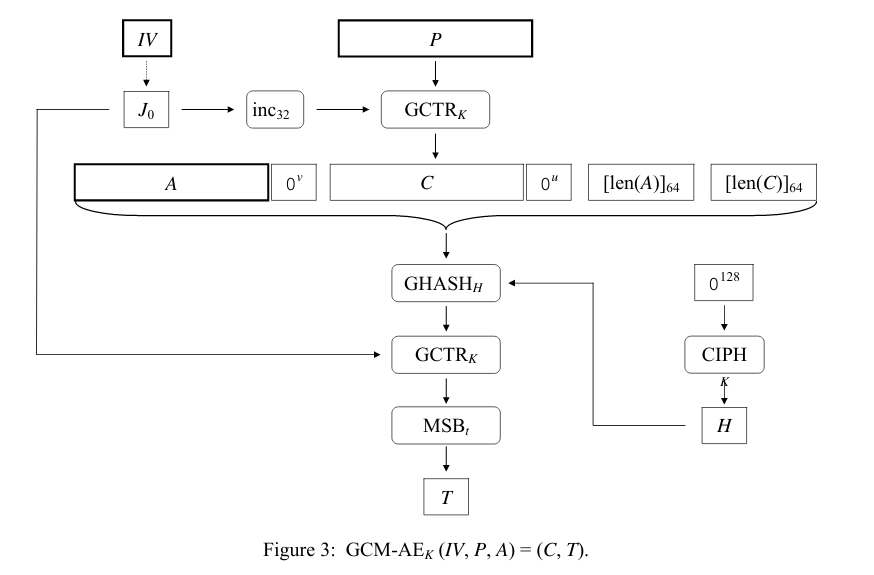

## 1.1. AES Block Cipher

### AES là gì?

**AES** (Advanced Encryption Standard) là symmetric block cipher được NIST chuẩn hóa năm 2001, thay thế DES.

- **Block size:** 128 bits (16 bytes)
- **Key size:** 128 / 192 / 256 bits
- **Cấu trúc:** Substitution-Permutation Network (SPN)

### Hoạt động cơ bản

AES mã hóa từng block 128-bit độc lập:

$$C = E_K(P)$$
$$P = D_K(C)$$

Trong đó:
- $P$: plaintext block (128 bits)
- $C$: ciphertext block (128 bits)  
- $K$: secret key
- $E_K$: encryption function
- $D_K$: decryption function

### Số rounds

| Key size | Rounds |
|----------|--------|
| 128 bits | 10 |
| 192 bits | 12 |
| 256 bits | 14 |

Mỗi round gồm 4 operations:
1. **SubBytes** - Thay thế byte qua S-box
2. **ShiftRows** - Dịch hàng
3. **MixColumns** - Trộn cột (trừ round cuối)
4. **AddRoundKey** - XOR với round key

### Block Cipher vs Stream Cipher

| | Block Cipher | Stream Cipher |
|---|---|---|
| Đơn vị xử lý | Block cố định (128 bits) | Từng bit/byte |
| AES thuộc loại | Block cipher | - |
| Cần mode of operation | Có (ECB, CBC, CTR, GCM...) | Không |

### Vấn đề với Block Cipher đơn thuần

AES chỉ mã hóa đúng 128 bits. Để mã hóa dữ liệu lớn hơn, ta cần **mode of operation**.

**ECB mode** (Electronic Codebook) - mã hóa từng block độc lập:

$$C_i = E_K(P_i)$$

**Vấn đề:** Cùng plaintext block → cùng ciphertext block → lộ pattern.

> GCM sử dụng **CTR mode** để khắc phục vấn đề này, kết hợp với **GHASH** để cung cấp authentication.

> AES visualize: https://formaestudio.com/rijndaelinspector/archivos/Rijndael_Animation_v4_eng-html5.html

## 1.2. Counter Mode (CTR)

### Ý tưởng

CTR mode biến block cipher thành **stream cipher** bằng cách mã hóa một counter thay vì plaintext trực tiếp.

$$\text{Keystream}_i = E_K(\text{Nonce} \| \text{Counter}_i)$$
$$C_i = P_i \oplus \text{Keystream}_i$$

### Quy trình mã hóa

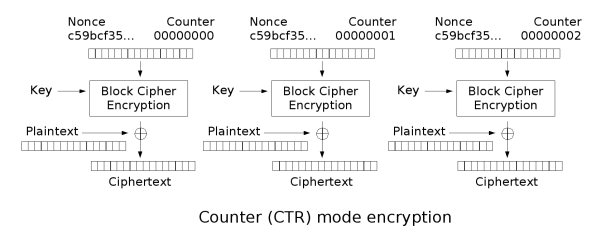


- **Nonce:** Unique cho mỗi message (do sender chọn)
- **Counter:** Tăng dần cho mỗi block trong cùng message (0, 1, 2, ...)

### Nếu Nonce bị reuse?

Khi hai messages $P$ và $P'$ dùng cùng nonce:

$$C = P \oplus \text{Keystream}$$
$$C' = P' \oplus \text{Keystream}$$

XOR hai ciphertexts:

$$C \oplus C' = P \oplus P'$$

> Attacker thu được XOR của hai plaintexts → có thể khôi phục nội dung nếu biết một trong hai, hoặc dùng frequency analysis.

**Đây là nền tảng của Forbidden Attack, nhưng GCM còn có vấn đề nghiêm trọng hơn: lộ authentication key $H$.**

## 1.3. GHASH và Galois Field $GF(2^{128})$

### Galois Field là gì?

**Galois Field** (hay Finite Field) $GF(2^{128})$ là tập hợp $2^{128}$ phần tử với phép cộng và nhân được định nghĩa đặc biệt.

Mỗi phần tử trong $GF(2^{128})$ được biểu diễn như một **đa thức bậc tối đa 127** với hệ số trong $\{0, 1\}$:

$$a = a_{127}x^{127} + a_{126}x^{126} + \cdots + a_1x + a_0$$

Hoặc đơn giản: một chuỗi 128 bits.


In [ ]:
from Crypto.Util.number import long_to_bytes as lb
from Crypto.Util.number import bytes_to_long as bl
from binascii import unhexlify, hexlify
from sage.all import *
import struct

F, a = GF(2^128, name="a", modulus=x^128 + x^7 + x^2 + x + 1).objgen()
R, x = PolynomialRing(F, name="x").objgen()
show(F.random_element())


### Phép cộng trong $GF(2^{128})$

Phép cộng = **XOR** từng bit:

$$a + b = a \oplus b$$

Ví dụ:



In [ ]:
10110...  (a)
⊕ 
11010...  (b)
──────────
01100...  (a + b)

In [390]:
elm1 = F.random_element()
elm2 = F.random_element()

show("elm1 = ", elm1)
show("elm2 = ", elm2)
show("elm1 + elm2 = ", elm1 + elm2)


'elm1 = ' a^126 + a^124 + a^123 + a^122 + a^121 + a^120 + a^119 + a^118 + a^117 + a^116 + a^115 + a^113 + a^112 + a^108 + a^107 + a^106 + a^105 + a^103 + a^102 + a^101 + a^100 + a^98 + a^97 + a^93 + a^90 + a^89 + a^88 + a^84 + a^83 + a^81 + a^78 + a^76 + a^75 + a^71 + a^69 + a^66 + a^63 + a^61 + a^59 + a^58 + a^53 + a^52 + a^51 + a^47 + a^46 + a^45 + a^43 + a^42 + a^41 + a^40 + a^39 + a^38 + a^37 + a^34 + a^33 + a^31 + a^28 + a^25 + a^24 + a^23 + a^21 + a^18 + a^17 + a^12 + a^11 + a^10 + a^6 + a^5 + a^4

'elm2 = ' a^124 + a^123 + a^122 + a^121 + a^119 + a^118 + a^117 + a^115 + a^112 + a^111 + a^110 + a^109 + a^108 + a^107 + a^106 + a^105 + a^104 + a^102 + a^101 + a^98 + a^93 + a^89 + a^88 + a^86 + a^83 + a^82 + a^75 + a^72 + a^71 + a^70 + a^69 + a^67 + a^65 + a^64 + a^63 + a^62 + a^60 + a^59 + a^58 + a^57 + a^55 + a^53 + a^51 + a^50 + a^47 + a^46 + a^43 + a^42 + a^41 + a^37 + a^34 + a^30 + a^27 + a^26 + a^25 + a^24 + a^22 + a^20 + a^19 + a^18 + a^16 + a^15 + a^8 + a^4 + a^3 + a^2 + a + 1

'elm1 + elm2 = ' a^126 + a^120 + a^116 + a^113 + a^111 + a^110 + a^109 + a^104 + a^103 + a^100 + a^97 + a^90 + a^86 + a^84 + a^82 + a^81 + a^78 + a^76 + a^72 + a^70 + a^67 + a^66 + a^65 + a^64 + a^62 + a^61 + a^60 + a^57 + a^55 + a^52 + a^50 + a^45 + a^40 + a^39 + a^38 + a^33 + a^31 + a^30 + a^28 + a^27 + a^26 + a^23 + a^22 + a^21 + a^20 + a^19 + a^17 + a^16 + a^15 + a^12 + a^11 + a^10 + a^8 + a^6 + a^5 + a^3 + a^2 + a + 1


### Phép nhân trong $GF(2^{128})$

Phép nhân phức tạp hơn - nhân đa thức rồi **mod** một đa thức bất khả quy (irreducible polynomial):

$$a \cdot b = (a \times b) \mod R(x)$$

GCM sử dụng:
$$R(x) = x^{128} + x^7 + x^2 + x + 1$$


In [391]:
elm3 = F.random_element()
elm4 = F.random_element()
show("elm3 =", elm3)
show("elm4 =", elm4)
show("elm3 * elm4 =", elm3*elm4)

'elm3 =' a^127 + a^126 + a^124 + a^123 + a^122 + a^121 + a^117 + a^115 + a^112 + a^111 + a^108 + a^106 + a^103 + a^102 + a^99 + a^98 + a^97 + a^96 + a^95 + a^92 + a^91 + a^83 + a^82 + a^81 + a^80 + a^79 + a^76 + a^72 + a^71 + a^69 + a^67 + a^65 + a^64 + a^63 + a^61 + a^60 + a^58 + a^57 + a^55 + a^54 + a^48 + a^46 + a^45 + a^42 + a^41 + a^40 + a^37 + a^35 + a^34 + a^33 + a^30 + a^28 + a^27 + a^26 + a^23 + a^22 + a^21 + a^19 + a^17 + a^16 + a^15 + a^11 + a^9 + a^8 + a^7 + a^5 + a^2 + a

'elm4 =' a^127 + a^126 + a^124 + a^121 + a^120 + a^118 + a^116 + a^115 + a^113 + a^112 + a^111 + a^110 + a^107 + a^104 + a^103 + a^102 + a^101 + a^98 + a^94 + a^93 + a^91 + a^86 + a^84 + a^80 + a^79 + a^73 + a^71 + a^69 + a^68 + a^67 + a^66 + a^64 + a^61 + a^60 + a^55 + a^54 + a^53 + a^50 + a^48 + a^46 + a^45 + a^44 + a^40 + a^32 + a^31 + a^29 + a^28 + a^24 + a^23 + a^22 + a^18 + a^15 + a^14 + a^13 + a^12 + a^10 + a^9 + a^8 + a^7 + a^4 + a^2 + 1

'elm3 * elm4 =' a^127 + a^125 + a^124 + a^122 + a^119 + a^117 + a^112 + a^111 + a^109 + a^108 + a^107 + a^106 + a^104 + a^101 + a^100 + a^98 + a^95 + a^89 + a^88 + a^86 + a^85 + a^78 + a^77 + a^73 + a^72 + a^71 + a^70 + a^69 + a^66 + a^65 + a^62 + a^61 + a^59 + a^56 + a^54 + a^53 + a^51 + a^49 + a^48 + a^46 + a^44 + a^36 + a^33 + a^30 + a^29 + a^28 + a^27 + a^25 + a^20 + a^19 + a^16 + a^15 + a^13 + a^12 + a^11 + a^10 + a^5 + a^3 + a^2 + a

In [ ]:
def bytes_to_polynomial(block, a):
    poly = 0 
    # pad to 128
    bin_block = bin(bl(block))[2 :].zfill(128)
    # reverse it to count correctly, wrong don't reverse it lol
    # bin_block = bin_block[::-1]
    for i in range(len(bin_block)):
        poly += a^i * int(bin_block[i])
    return poly

def polynomial_to_bytes(poly):
    return lb(int(bin(poly.to_integer())[2:].zfill(128)[::-1], 2))


pt = b'hello'
pt_poly = bytes_to_polynomial(pt, a)
print('pt ---------> polynomial: ', pt_poly)
print(polynomial_to_bytes(pt_poly))


### GHASH Function

**GHASH** là hàm hash dựa trên phép nhân trong $GF(2^{128})$:

$$\text{GHASH}_H(X_1, X_2, \ldots, X_m) = Y_m$$

Trong đó:
- $H = E_K(0^{128})$ là **authentication key** (hash key)
- $X_i$ là các block 128-bit của input
- $Y_i$ được tính đệ quy

### Công thức GHASH

$$Y_0 = 0^{128}$$
$$Y_i = (Y_{i-1} \oplus X_i) \cdot H$$




### GHASH là đa thức

Khai triển công thức:

$$Y_m = X_1 \cdot H^m + X_2 \cdot H^{m-1} + \cdots + X_m \cdot H$$

Hay viết gọn:

$$Y_m = \sum_{i=1}^{m} X_i \cdot H^{m-i+1}$$

> **Quan trọng:** GHASH là một **đa thức bậc $m$** theo biến $H$ trong $GF(2^{128})$.

## 1.4. Cấu trúc AES-GCM

AES-GCM kết hợp **CTR mode** (confidentiality) và **GHASH** (authentication) thành một AEAD scheme.

### Input/Output

**Input:**
- $K$: Secret key (128/256 bits)
- $IV$: Initialization vector / Nonce (96 bits khuyến nghị)
- $P$: Plaintext
- $A$: Additional Authenticated Data (AAD) - không mã hóa, chỉ authenticate

**Output:**
- $C$: Ciphertext (cùng độ dài với $P$)
- $T$: Authentication tag (128 bits)

### Quy trình Encryption

**Bước 1:** Tính authentication key $H$
$$H = E_K(0^{128})$$

**Bước 2:** Tạo initial counter $J_0$
- Nếu $|IV| = 96$: $J_0 = IV \| 0^{31} \| 1$
- Nếu $|IV| \neq 96$: $J_0 = \text{GHASH}_H(IV)$

**Bước 3:** Mã hóa plaintext bằng CTR mode
$$C_i = P_i \oplus E_K(J_0 + i)$$

**Bước 4:** Tính authentication tag
$$T = \text{GHASH}_H(A \| C \| \text{len}(A) \| \text{len}(C)) \oplus E_K(J_0)$$

### Sơ đồ

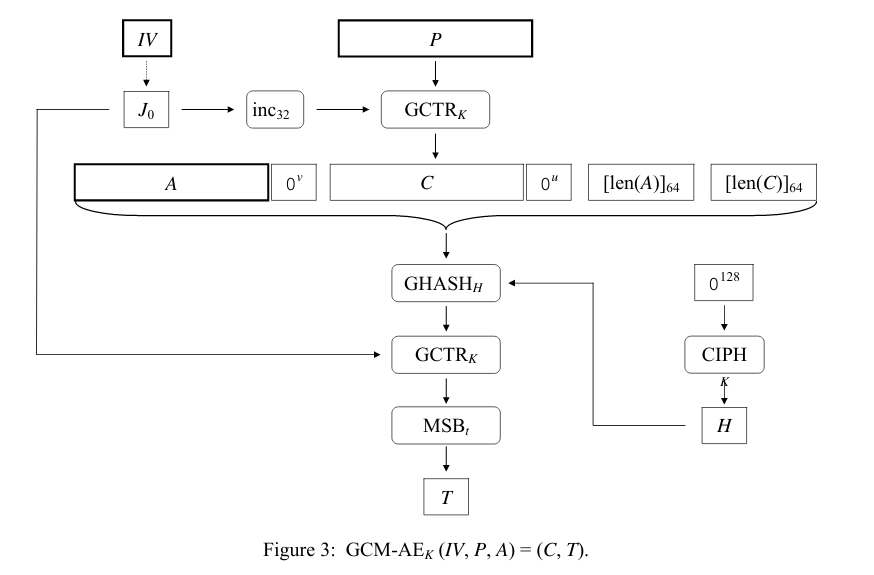


### Quy trình Decryption

**Bước 1:** Tính $H$ và $J_0$ (giống encryption)

**Bước 2:** Tính expected tag $T'$ từ $A$ và $C$

**Bước 3:** So sánh $T' == T$
- Nếu **không khớp**: REJECT, không trả về gì
- Nếu **khớp**: tiếp tục

**Bước 4:** Giải mã ciphertext
$$P_i = C_i \oplus E_K(J_0 + i)$$

### Tại sao cần AAD?

AAD cho phép authenticate metadata mà không cần mã hóa:

| Ví dụ | AAD | Plaintext |
|-------|-----|-----------|
| Network packet | Header (src, dst, length) | Payload |
| Database | Row ID, timestamp | Sensitive data |
| File encryption | Filename, permissions | File content |




# 2. Vai trò của Nonce trong AES-GCM

## 2.1. Nonce là gì và yêu cầu bảo mật

### Nonce trong AES-GCM

**Nonce** (Number used once) trong AES-GCM thường được gọi là **IV** (Initialization Vector):

- Độ dài khuyến nghị: **96 bits** (12 bytes)
- Được truyền công khai cùng ciphertext
- PHẢI unique cho mỗi message với cùng key

### Cấu trúc với 96-bit nonce
```
┌─────────────────────────────────────────┐
│Nonce (96 bits)      │ Counter (32 bits) │
└─────────────────────────────────────────┘
│
▼
J_0 = Nonce || 0x00000001
```

Counter bắt đầu từ 1 và tăng dần cho mỗi block.

### Yêu cầu bảo mật

| Yêu cầu | Mô tả |
|---------|-------|
| **Unique** | Không được trùng với bất kỳ nonce nào trước đó (với cùng key) |
| **Unpredictable** | Không bắt buộc, nhưng tốt hơn nếu có |
| **Public** | Có thể truyền công khai, không cần bảo mật |

### So sánh với ECDSA nonce

| | ECDSA nonce | AES-GCM nonce |
|---|---|---|
| Độ dài | 256 bits | 96 bits |
| Bảo mật | PHẢI secret | Có thể public |
| Unique | PHẢI unique | PHẢI unique |
| Hậu quả reuse | Lộ private key | Lộ auth key $H$ + plaintext XOR |






# 3. Forbidden Attack

## 3.1. Mô tả lỗ hổng

### Kịch bản

Hai messages $P_1$ và $P_2$ được mã hóa với **cùng key $K$ và cùng nonce $N$**:

| | Message 1 | Message 2 |
|---|---|---|
| Plaintext | $P_1$ | $P_2$ |
| AAD | $A_1$ | $A_2$ |
| Nonce | $N$ | $N$ (reuse!) |
| Ciphertext | $C_1$ | $C_2$ |
| Tag | $T_1$ | $T_2$ |

### Hậu quả

Attacker có thể:

1. **Khôi phục $P_1 \oplus P_2$** (XOR của hai plaintexts)
2. **Khôi phục authentication key $H$**
3. **Forge** ciphertext mới với tag hợp lệ

### Tại sao leak XOR?

Cùng nonce → cùng keystream:

$$C_1 = P_1 \oplus \text{Keystream}$$
$$C_2 = P_2 \oplus \text{Keystream}$$

XOR hai ciphertexts:

$$C_1 \oplus C_2 = P_1 \oplus P_2$$

### Tại sao leak $H$?

Công thức tag:

$$T = \text{GHASH}_H(A \| C \| \text{len}) \oplus E_K(J_0)$$

Với cùng nonce, $E_K(J_0)$ **giống nhau** cho cả hai messages. Gọi $M = E_K(J_0)$:

$$T_1 = \text{GHASH}_H(X_1) \oplus M$$
$$T_2 = \text{GHASH}_H(X_2) \oplus M$$

XOR hai tags:

$$T_1 \oplus T_2 = \text{GHASH}_H(X_1) \oplus \text{GHASH}_H(X_2)$$

Mask $M$ bị triệt tiêu → attacker có phương trình chỉ chứa ẩn $H$.

### GHASH là đa thức

Nhắc lại: GHASH là đa thức theo $H$ trong $GF(2^{128})$:

$$\text{GHASH}_H(X_1, \ldots, X_m) = X_1 H^m + X_2 H^{m-1} + \cdots + X_m H$$

Do đó:

$$T_1 \oplus T_2 = \text{GHASH}_H(X_1) \oplus \text{GHASH}_H(X_2) = f(H)$$

Trong đó $f(H)$ là **đa thức bậc $m$** với hệ số đã biết (từ $C_1, C_2, A_1, A_2$).

### Phương trình cần giải

$$f(H) = 0 \quad \text{trong } GF(2^{128})$$

Đa thức bậc $m$ có tối đa $m$ nghiệm → attacker thử từng nghiệm để tìm $H$ đúng.

> **Kết luận:** Chỉ cần **2 ciphertexts** với cùng nonce, attacker có thể khôi phục $H$ và forge messages tùy ý.


## 3.2. Khôi phục Authentication Key $H$

### Thiết lập

Cho hai ciphertexts $(C_1, T_1)$ và $(C_2, T_2)$ với cùng nonce, giả sử:
- Không có AAD (để đơn giản)
- Mỗi ciphertext có 2 blocks: $C_1 = C_1^{(1)} \| C_1^{(2)}$ và $C_2 = C_2^{(1)} \| C_2^{(2)}$

### Công thức GHASH

$$\text{GHASH}_H(C) = C^{(1)} H^3 + C^{(2)} H^2 + L \cdot H$$

Trong đó $L = \text{len}(A) \| \text{len}(C)$ là block chứa độ dài.

### Tag equations

$$T_1 = C_1^{(1)} H^3 + C_1^{(2)} H^2 + L_1 H + M$$
$$T_2 = C_2^{(1)} H^3 + C_2^{(2)} H^2 + L_2 H + M$$

Với $M = E_K(J_0)$ là mask (giống nhau vì cùng nonce).

### XOR hai equations

$$T_1 \oplus T_2 = (C_1^{(1)} \oplus C_2^{(1)}) H^3 + (C_1^{(2)} \oplus C_2^{(2)}) H^2 + (L_1 \oplus L_2) H$$

Đặt:
- $D = T_1 \oplus T_2$
- $a = C_1^{(1)} \oplus C_2^{(1)}$
- $b = C_1^{(2)} \oplus C_2^{(2)}$
- $c = L_1 \oplus L_2$

Ta được phương trình:

$$a H^3 + b H^2 + c H + D = 0 \quad \text{trong } GF(2^{128})$$

### Giải phương trình trong $GF(2^{128})$

**Bước 1:** Xây dựng đa thức

$$f(H) = a H^3 + b H^2 + c H + D$$

**Bước 2:** Phân tích thành nhân tử (factorization) trong $GF(2^{128})$

**Bước 3:** Tìm nghiệm (roots)

Đa thức bậc 3 có tối đa 3 nghiệm trong $GF(2^{128})$.

### Xác định nghiệm đúng

Nếu có nhiều nghiệm, attacker thử từng $H$ bằng cách:

1. Forge một ciphertext mới với $H$ đó
2. Gửi đến server/victim
3. Nếu được chấp nhận → đúng $H$

Hoặc nếu có **3+ ciphertexts** cùng nonce:
- Lập thêm phương trình
- $H$ đúng phải thỏa mãn tất cả

In [418]:
from sage.all import *

# === Setup GF(2^128) với irreducible polynomial của GCM ===
F, a = GF(2^128, name="a", modulus=x^128 + x^7 + x^2 + x + 1).objgen()
R, x = PolynomialRing(F, name="x").objgen()

# === Tạo phương trình với hệ số random ===
a3 = F.random_element()
a2 = F.random_element()
a1 = F.random_element()
a0 = F.random_element()

# Đa thức bậc 3
f = a3 * x^3 + a2 * x^2 + a1 * x + a0
show(f)

# === Tìm nghiệm ===
roots = f.roots()

print("=== Nghiệm ===")
print(f"Số nghiệm: {len(roots)}")
for root, mult in roots:
    show(f"  x = {root}")
    print(f"      f(x) = {f(root)}")


(a^127 + a^126 + a^125 + a^123 + a^122 + a^120 + a^119 + a^118 + a^116 + a^115 + a^111 + a^110 + a^109 + a^107 + a^106 + a^103 + a^102 + a^101 + a^100 + a^99 + a^98 + a^97 + a^96 + a^95 + a^91 + a^89 + a^87 + a^85 + a^84 + a^83 + a^82 + a^81 + a^80 + a^79 + a^75 + a^73 + a^72 + a^68 + a^66 + a^65 + a^62 + a^61 + a^60 + a^59 + a^58 + a^55 + a^46 + a^44 + a^43 + a^41 + a^39 + a^38 + a^36 + a^34 + a^33 + a^32 + a^30 + a^29 + a^26 + a^25 + a^24 + a^23 + a^22 + a^16 + a^15 + a^14 + a^13 + a^12 + a^11 + a^9 + a^7 + a^4 + a^2 + a + 1)*x^3 + (a^127 + a^123 + a^118 + a^117 + a^116 + a^115 + a^110 + a^108 + a^107 + a^106 + a^104 + a^98 + a^97 + a^92 + a^91 + a^89 + a^88 + a^86 + a^85 + a^84 + a^83 + a^81 + a^80 + a^79 + a^71 + a^70 + a^69 + a^68 + a^65 + a^64 + a^63 + a^62 + a^60 + a^58 + a^56 + a^55 + a^54 + a^53 + a^52 + a^51 + a^49 + a^47 + a^46 + a^42 + a^40 + a^38 + a^36 + a^34 + a^32 + a^29 + a^25 + a^24 + a^21 + a^19 + a^18 + a^17 + a^13 + a^11 + a^10 + a^9 + a^8 + a^7 + a^5 + a^4 + a^2 + a + 1)*x^2 + (a^127 + a^126 + a^124 + a^123 + a^119 + a^118 + a^117 + a^115 + a^113 + a^108 + a^105 + a^103 + a^102 + a^101 + a^100 + a^98 + a^97 + a^95 + a^93 + a^92 + a^91 + a^90 + a^89 + a^88 + a^86 + a^84 + a^81 + a^79 + a^78 + a^76 + a^75 + a^74 + a^73 + a^70 + a^64 + a^59 + a^55 + a^54 + a^53 + a^49 + a^48 + a^46 + a^43 + a^42 + a^39 + a^38 + a^35 + a^32 + a^30 + a^29 + a^28 + a^27 + a^25 + a^23 + a^22 + a^21 + a^18 + a^17 + a^16 + a^15 + a^12 + a^7 + a^2 + a)*x + a^126 + a^123 + a^121 + a^119 + a^118 + a^116 + a^115 + a^114 + a^110 + a^109 + a^107 + a^105 + a^102 + a^100 + a^99 + a^98 + a^97 + a^95 + a^94 + a^93 + a^90 + a^89 + a^87 + a^86 + a^85 + a^82 + a^76 + a^73 + a^71 + a^70 + a^67 + a^65 + a^64 + a^59 + a^57 + a^55 + a^53 + a^52 + a^51 + a^49 + a^48 + a^47 + a^46 + a^43 + a^42 + a^41 + a^40 + a^39 + a^37 + a^32 + a^27 + a^23 + a^22 + a^21 + a^19 + a^18 + a^17 + a^16 + a^15 + a^12 + a^10 + a^9 + a^7 + a^3 + a

=== Nghiệm ===
Số nghiệm: 0


## 3.3. Giải mã plaintext (XOR Attack)

### Nguyên lý

Khi nonce bị reuse, cùng keystream được sử dụng:

$$C_1 = P_1 \oplus K_s$$
$$C_2 = P_2 \oplus K_s$$

XOR hai ciphertexts:

$$C_1 \oplus C_2 = P_1 \oplus P_2$$

### Kịch bản tấn công

**Known-plaintext attack:**
- Attacker biết $P_1$ (ví dụ: HTTP header cố định)
- Tính $P_2 = P_1 \oplus C_1 \oplus C_2$

**Crib-dragging:**
- Attacker đoán một phần của $P_1$ hoặc $P_2$
- Thử XOR với $C_1 \oplus C_2$ tại các vị trí khác nhau
- Nếu kết quả có nghĩa (readable text) → đoán đúng

### Ví dụ



### Với nhiều ciphertexts

Nếu có $n$ ciphertexts cùng nonce:

$$C_1 \oplus C_2 = P_1 \oplus P_2$$
$$C_1 \oplus C_3 = P_1 \oplus P_3$$
$$\vdots$$
$$C_1 \oplus C_n = P_1 \oplus P_n$$

Càng nhiều ciphertexts → càng dễ phân tích frequency và khôi phục plaintext.

### So sánh với ECDSA

| | ECDSA Nonce Reuse | AES-GCM Nonce Reuse |
|---|---|---|
| Leak trực tiếp | Private key $d$ | Auth key $H$ + $P_1 \oplus P_2$ |
| Cần biết plaintext? | Không | Không (nhưng giúp ích) |
| Forgery? | Ký message bất kỳ | Tạo ciphertext hợp lệ bất kỳ |


In [1]:
from Crypto.Util.number import long_to_bytes as lb
from Crypto.Util.number import bytes_to_long as bl
from binascii import unhexlify, hexlify
from sage.all import *
import struct

def bytes_to_polynomial(block, a):
    poly = 0 
    # pad to 128
    bin_block = bin(bl(block))[2 :].zfill(128)
    # reverse it to count correctly, wrong don't reverse it lol
    # bin_block = bin_block[::-1]
    for i in range(len(bin_block)):
        poly += a^i * int(bin_block[i])
    return poly

def polynomial_to_bytes(poly):
    return lb(int(bin(poly.to_integer())[2:].zfill(128)[::-1], 2))

def convert_to_blocks(ciphertext):
    return [ciphertext[i:i + 16] for i in range(0 , len(ciphertext), 16)]

def xor(s1, s2):
    if(len(s1) == 1 and len(s1) == 1):
        return bytes([ord(s1) ^^ ord(s2)])
    else:
        return bytes(x ^^ y for x, y in zip(s1, s2))

F, a = GF(2^128, name="a", modulus=x^128 + x^7 + x^2 + x + 1).objgen()
R, x = PolynomialRing(F, name="x").objgen()

# Set correct values
C1 = convert_to_blocks(bytes.fromhex(""))
T1 = bytes.fromhex("")
C2 = convert_to_blocks(bytes.fromhex(""))
T2 = bytes.fromhex("")
C3 = convert_to_blocks(bytes.fromhex(""))

L = struct.pack(">QQ", 0 * 8, len(C1) * 8)
C1_p = [bytes_to_polynomial(C1[i], a) for i in range(len(C1))]
C2_p = [bytes_to_polynomial(C2[i], a) for i in range(len(C2))]
C3_p = [bytes_to_polynomial(C3[i], a) for i in range(len(C3))]
T1_p = bytes_to_polynomial(T1, a)
T2_p = bytes_to_polynomial(T2, a)
L_p = bytes_to_polynomial(L, a)

# Here G_1 is already modified to include the tag
G_1 = (C1_p[0] * x^3) + (C1_p[1] * x^2) + (L_p * x) + T1_p
G_2 = (C2_p[0] * x^3) + (C2_p[1] * x^2) + (L_p * x) + T2_p
G_3 = (C3_p[0] * x^3) + (C3_p[1] * x^2) + (L_p * x)
P = G_1 + G_2

for H, _ in P.roots():
    EJ = G_1(H)
    T3 = G_3(H) + EJ
    print("H: " + str(H) + "\nT3: " + str(polynomial_to_bytes(T3).hex()))


IndexError: list index out of range